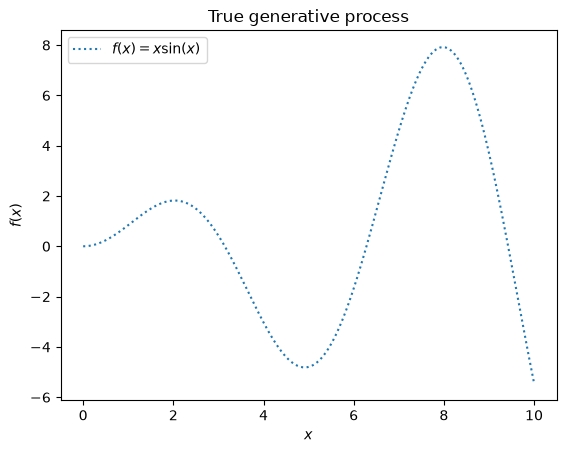

In [2]:
import numpy as np
X = np.linspace (start=0, stop=10, num=1_000).reshape(-1,1)
y = np.squeeze(X * np.sin(X))

import matplotlib.pyplot as plt
plt.plot(X, y, label=r"$f(x) =x \sin(x)$", linestyle="dotted")
plt.legend()
plt.xlabel("$x$")
plt.ylabel("$f(x)$")
_ = plt.title("True generative process")

In [3]:
rng = np.random.RandomState(1)
training_indices = rng.choice(np.arange(y.size), size=6, replace=False)
X_train, y_train = X[training_indices], y[training_indices]

That code above has created 1000 data pints between 0 and 10 (evenly spaced) for x and then for each of those points assigned y as x*sinx and then plotted those coordinate pairs giving the graph of y=x*sinx. Then it randomly took 6 of those coordinate pairs and stored them which we will now use for our GPR.

In [4]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
kernel = 1 * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2))
gaussian_process = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=9)
gaussian_process.fit(X_train, y_train)
gaussian_process.kernel_

5.02**2 * RBF(length_scale=1.43)

The code above imports the Gaussian Process Regression model. Then creates a kernel (which does the measures of similarity between points). Then it optimises the hyperparameters which is what is seen in the output. This optimisation is done from 9 addition trials (n_restarts_optimizer=9) which means 10 total trials.

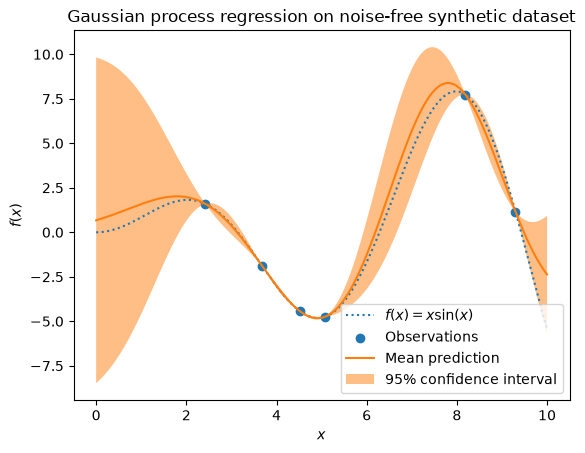

In [7]:
mean_prediction, std_prediction = gaussian_process.predict(X, return_std=True)
plt.plot(X, y, label=r"$f(x) = x \sin(x)$", linestyle="dotted")
plt.scatter(X_train, y_train, label="Observations")
plt.plot(X, mean_prediction, label="Mean prediction")
plt.fill_between(
    X.ravel(),
    mean_prediction - 1.96 * std_prediction,
    mean_prediction + 1.96 * std_prediction,
    alpha=0.5,
    label="95% confidence interval"
)
plt.legend()
plt.xlabel("$x$")
plt.ylabel("$f(x)$")
_ = plt.title("Gaussian process regression on noise-free synthetic dataset")

What the code above did was use the Gaussian Process to predict the mean and standard deviation and each x and then plot the mean and a range of 95% confidence. The mean must go through the observed points because there are no x values that have multiple y values and also the kernels that we have selected essentially assume no noise and also because we optimised the hyperparameters of the kernel sufficiently. 

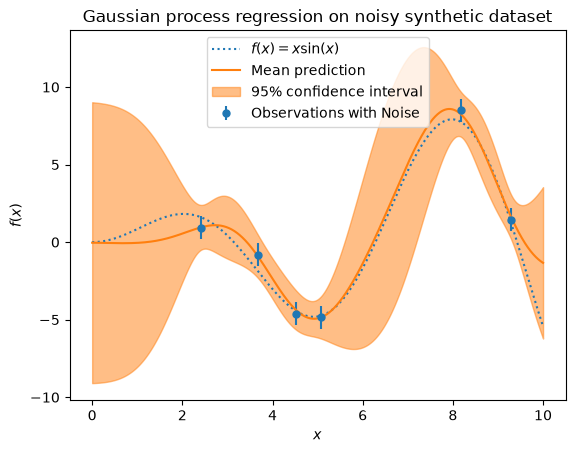

In [10]:
noise_std = 0.75
y_train_noisy = y_train + rng.normal(loc=0, scale=noise_std, size=y_train.shape)
gaussian_process= GaussianProcessRegressor(
    kernel=kernel, alpha=noise_std**2, n_restarts_optimizer=9
)
gaussian_process.fit(X_train, y_train_noisy)
mean_prediction, std_prediction = gaussian_process.predict(X, return_std=True)
plt.plot(X, y, label=r"$f(x) = x \sin(x)$", linestyle="dotted")
plt.errorbar(
    X_train,
    y_train_noisy,
    noise_std,
    linestyle="None",
    color="tab:blue",
    marker=".",
    markersize=10,
    label="Observations with Noise",
)
plt.plot(X, mean_prediction, label="Mean prediction")
plt.fill_between(
    X.ravel(),
    mean_prediction - 1.96 * std_prediction,
    mean_prediction + 1.96 * std_prediction,
    color="tab:orange",
    alpha=0.5,
    label=r"95% confidence interval"
)
plt.legend()
plt.xlabel("$x$")
plt.ylabel("$f(x)$")
_ = plt.title("Gaussian process regression on noisy synthetic dataset")

The code above is the same as before the only difference now is that the initial alpha value is the variance of the noice (std squared) which is a good starting estimate for the hyperparameter of the kernel

4.28**2 * RBF(length_scale=1.1) + WhiteKernel(noise_level=7.63e-08)


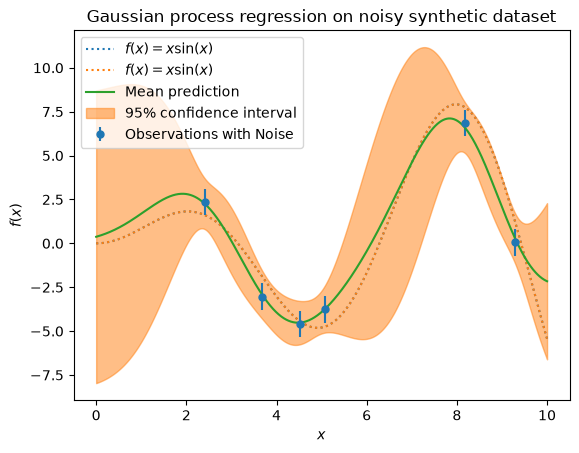

In [5]:
import numpy as np
X = np.linspace (start=0, stop=10, num=1_000).reshape(-1,1)
y = np.squeeze(X * np.sin(X))

import matplotlib.pyplot as plt
plt.plot(X, y, label=r"$f(x) =x \sin(x)$", linestyle="dotted")
plt.legend()
plt.xlabel("$x$")
plt.ylabel("$f(x)$")
_ = plt.title("True generative process")
rng = np.random.RandomState(1)
training_indices = rng.choice(np.arange(y.size), size=6, replace=False)
X_train, y_train = X[training_indices], y[training_indices]
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from sklearn.gaussian_process.kernels import WhiteKernel
kernel = 1 * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) + WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-10, 1e+1))
gaussian_process = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=9)
gaussian_process.fit(X_train, y_train)
gaussian_process.kernel_
noise_std = 0.75
y_train_noisy = y_train + rng.normal(loc=0, scale=noise_std, size=y_train.shape)
gaussian_process= GaussianProcessRegressor(
    kernel=kernel, alpha=noise_std**2, n_restarts_optimizer=9
)
gaussian_process.fit(X_train, y_train_noisy)
mean_prediction, std_prediction = gaussian_process.predict(X, return_std=True)
plt.plot(X, y, label=r"$f(x) = x \sin(x)$", linestyle="dotted")
plt.errorbar(
    X_train,
    y_train_noisy,
    noise_std,
    linestyle="None",
    color="tab:blue",
    marker=".",
    markersize=10,
    label="Observations with Noise",
)
plt.plot(X, mean_prediction, label="Mean prediction")
plt.fill_between(
    X.ravel(),
    mean_prediction - 1.96 * std_prediction,
    mean_prediction + 1.96 * std_prediction,
    color="tab:orange",
    alpha=0.5,
    label=r"95% confidence interval"
)
plt.legend()
plt.xlabel("$x$")
plt.ylabel("$f(x)$")
_ = plt.title("Gaussian process regression on noisy synthetic dataset")

print(gaussian_process.kernel_)

This final part is just an attempt to use the White Kernel. It worked but the actual change is not noticable for the areas near points. it just leads to more uncertainty in areas further from what is explored.